<table width="100%" style="border: none; border-collapse: collapse; margin: 0; padding: 0;">
<tr style="border: none; background: none;">
<td width="50%" style="border: none; border-bottom: 2px solid #555555; vertical-align: top; padding-bottom: 10px; text-align: left;">
<h2 style="margin: 0; padding: 0; line-height: 1;"><span style="color: #B30033;">▍</span> Práctica 3:</h2>
<h1 style="margin: 5px 0 0 0; font-size: 200%; line-height: 1.2;">Aprendizaje de modelos basados en redes neuronales</h1>
</td>
<td width="50%" style="border: none; border-bottom: 2px solid #555555; vertical-align: bottom; padding-bottom: 10px; text-align: right;">
<div style="display: inline-block; border-left: 2px solid #555555; padding-left: 15px; text-align: right;">
<p style="margin: 0 0 10px 0; font-size: 140%; font-weight: bold;">Minería de Datos, 2025-26</p>
<p style="margin: 0; font-size: 100%; color: #666666;">José Antonio Gámez Martín<a href="mailto:Jose.Gamez@uclm.es" style="color: #888888; text-decoration: none; margin-left: 10px; font-size: 80%;">✉ Jose.Gamez@uclm.es</a></p>
<p style="margin: 5px 0 0 0; font-size: 100%; color: #666666;">Pablo Torrijos Arenas<a href="mailto:Pablo.Torrijos@uclm.es" style="color: #888888; text-decoration: none; margin-left: 10px; font-size: 80%;">✉ Pablo.Torrijos@uclm.es</a></p>
</div>
</td>
</tr>
</table>
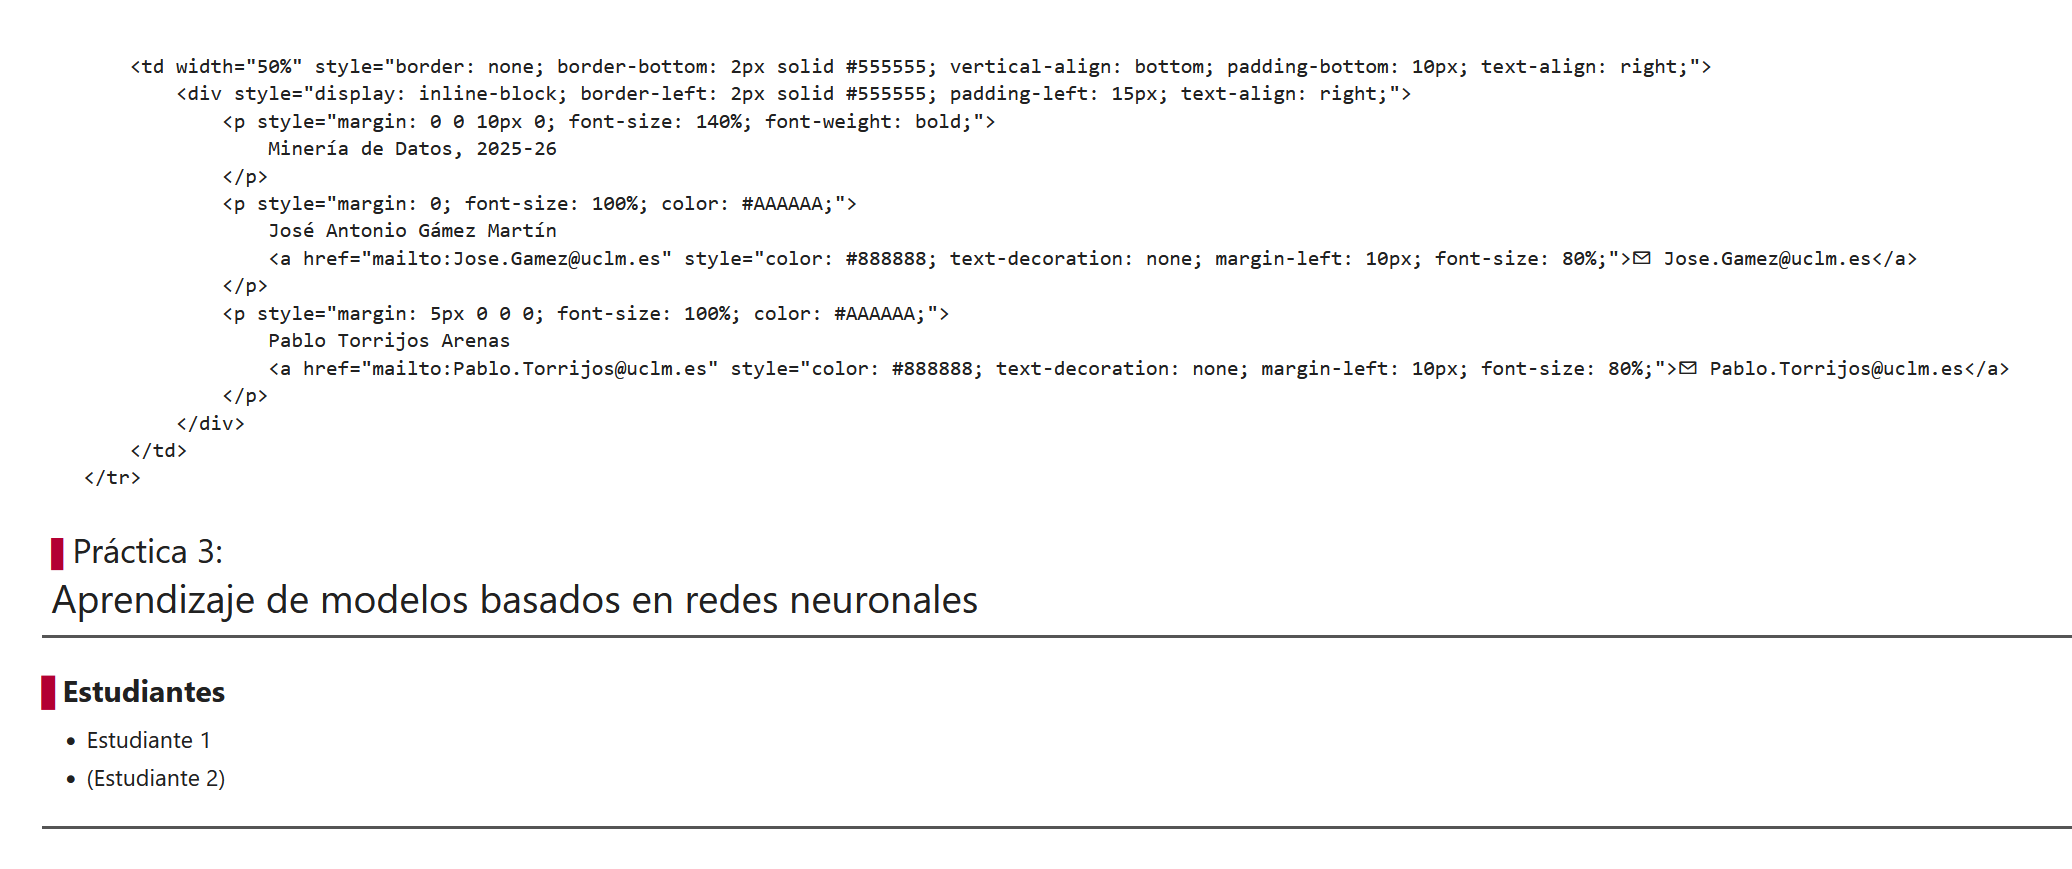

<h3 style="margin: 0 0 10px 0; font-weight: bold;">
<span style="color: #B30033; font-size: 120%; margin-right: 5px;">▍</span>Estudiantes</h3>

* Diego García Díaz
* Alberto Pérez Álvarez

## 1. Introducción

En esta práctica aplicaremos **Deep Learning** para clasificar imágenes satelitales del conjunto de datos **EuroSAT**. El objetivo es identificar el uso del suelo (bosques, zonas industriales, cultivos, etc.) utilizando tanto redes diseñadas desde cero como técnicas de Transfer Learning.

### Instrucciones de Dataset (Kaggle)
Para que esta libreta funcione, debes añadir el siguiente dataset a tu entorno (en principio, si clonais la libreta lo deberíais de tener por defecto):
1.  En el menú derecho, pulsa **Add Input**.
2.  Busca **"EuroSAT Dataset"** (del usuario *Gota Dahiya*).
3.  Añádelo pulsando el botón `+`.

### Configuración Inicial
Asegúrate de tener activada la **GPU** (T4 x2 o P100) para acelerar el entrenamiento.

In [2]:
#!pip install "protobuf==3.20.3" > /dev/null 2>&1  #Si no, da un error de compatibilidad entre liberías.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetV2B0
from transformers import TFViTModel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import pathlib
import PIL.Image
import time
from sklearn.metrics import classification_report, confusion_matrix
import gc 

In [3]:
# Reproducibilidad
SEED = 2025
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow Version: 2.16.1
GPU Available: False


---

## 2. Carga y Gestión de Datos

Utilizaremos `tf.keras.utils.image_dataset_from_directory`. Esta función crea un generador de datos que carga las imágenes del disco bajo demanda, evitando saturar la memoria RAM.

In [4]:
#data_dir = pathlib.Path('/kaggle/input/eurosat-dataset/EuroSAT')

# Ruta estándar basada en el dataset eurosat-dataset. Contiene las imágenes .jpg, mientras que 'EuroSATallBands' contiene archivos .tif
KAGGLE_PATH = '/kaggle/input/eurosat-dataset/EuroSAT'
# Ruta que tendria en local.
LOCAL_PATH = './EuroSAT' 

# Kaggle siempre define la variable de entorno 'KAGGLE_KERNEL_RUN_TYPE'
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None:
    print("Entorno de Kaggle")
    data_dir = KAGGLE_PATH
else:
    data_dir = LOCAL_PATH
    print("Entorno Local:",data_dir)
    
data_dir = pathlib.Path(data_dir)

# Verificación del contenido
all_images = list(data_dir.glob('*/*.jpg'))
image_count = len(all_images)
print(f"Total de imágenes encontradas: {image_count}")

# Verificación de dimensiones reales
first_image = PIL.Image.open(all_images[0])
print(f"Dimensiones reales de una imagen de muestra: {first_image.size}")
print(f"Formato de imagen: {first_image.format}")

# Parámetros Globales
# Ajustamos las constantes al tamaño real detectado (debería ser 64x64)
BATCH_SIZE = 64
IMG_HEIGHT = 64
IMG_WIDTH = 64

Entorno Local: ./EuroSAT
Total de imágenes encontradas: 27000
Dimensiones reales de una imagen de muestra: (64, 64)
Formato de imagen: JPEG


### 2.1 Creación de Pipelines (`tf.data`) y División Train/Val/Test

Para garantizar la robustez de los resultados, dividiremos los datos de la siguiente manera:
* **70% Entrenamiento:** Para ajustar los pesos de los modelos.
* **15% Validación:** Para ajustar hiperparámetros y *Early Stopping*.
* **15% Test:** Conjunto para la evaluación final.

In [5]:
# Cargamos el dataset completo sin dividir inicialmente
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    label_mode='int'
)

class_names = full_ds.class_names
print(f"Clases encontradas: {class_names}")

# Calculamos el número de batches
n_batches = tf.data.experimental.cardinality(full_ds).numpy()

train_size = int(0.7 * n_batches)
val_size = int(0.15 * n_batches)
test_size = n_batches - train_size - val_size

print(f"Batches -> Train: {train_size}, Val: {val_size}, Test: {test_size}")

# Realizar la división usando take() y skip()
train_ds = full_ds.take(train_size)
remaining_ds = full_ds.skip(train_size)
val_ds = remaining_ds.take(val_size)
test_ds = remaining_ds.skip(val_size)

Found 27000 files belonging to 11 classes.
Clases encontradas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'allBands']
Batches -> Train: 295, Val: 63, Test: 64


### 2.2 Optimización (Performance)
Usamos `.cache()` y `.prefetch()` para que la GPU no tenga que esperar a la carga de datos.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### 2.3 Análisis Exploratorio (EDA)
En esta práctica no nos vamos a centar en el EDA y preprocesamiento. Solo se piden (obligatoriamente) las siguientes tareas:

**Tarea:**
1.  Visualiza una cuadrícula de imágenes del conjunto de entrenamiento con sus etiquetas (preferiblemente mostrando alguna de cada clase).
2.  Analiza si el dataset está balanceado mostrando un gráfico de barras con la cantidad de imágenes por clase.

2025-12-03 11:39:38.503620: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


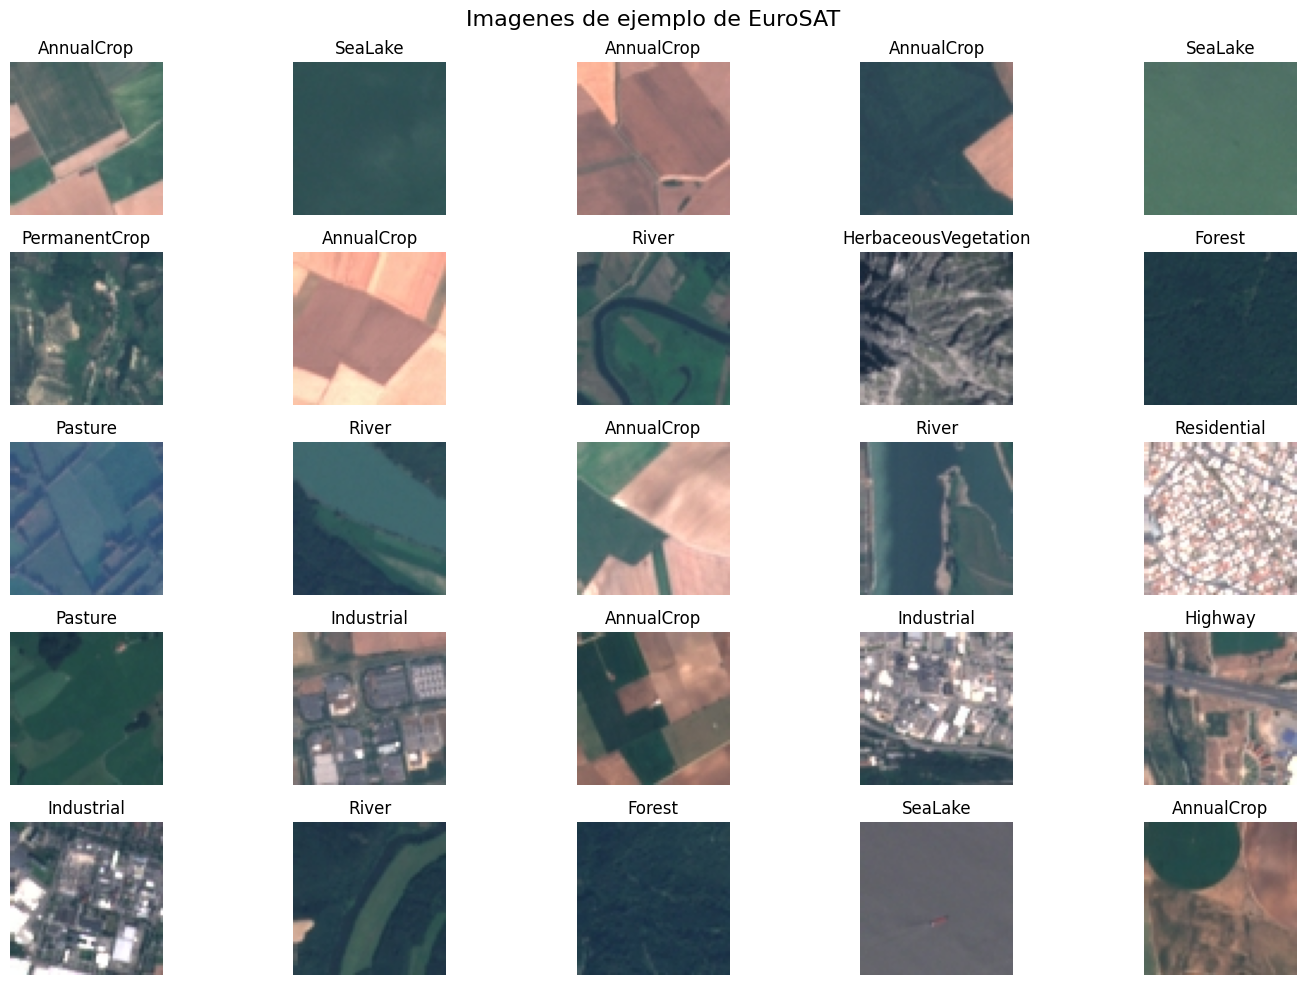

2025-12-03 11:39:41.268003: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


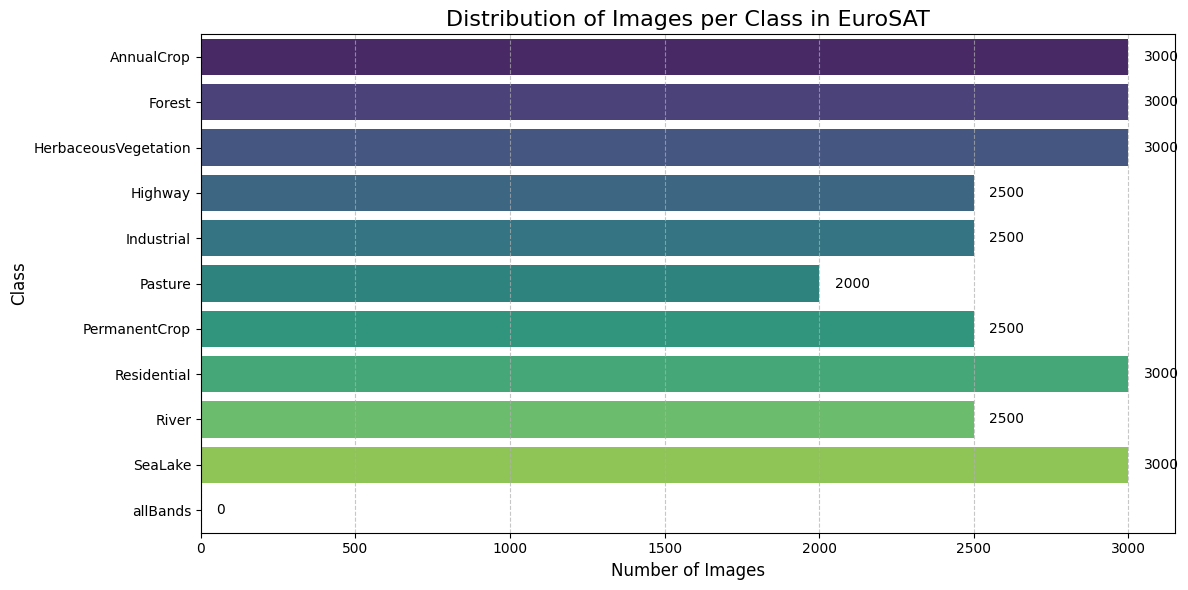

Media de imagenes: 2454.55
Desviacion estandar: 879.05


In [7]:
plt.figure(figsize=(15, 10))

for images, labels in train_ds.take(1):
    for i in range(25): # Seleccionamos las primeras 25 aleatorias
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        label_index = int(labels[i]) # Cogemos el label de la imagen y lo colocamos junto a ella
        plt.title(class_names[label_index])
        plt.axis("off")

plt.suptitle("Imagenes de ejemplo de EuroSAT", fontsize=16)
plt.tight_layout()
plt.show()


class_counts = {name: 0 for name in class_names}
for _, labels in full_ds:
    for label in labels:
        class_name = class_names[int(label)]
        class_counts[class_name] += 1

# Lo hacemos con un dataframe, pues es mas facil hacer el plot.
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Class', data=df_counts, palette='viridis', hue='Class', legend=False)
plt.title('Distribution of Images per Class in EuroSAT', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the number at the end of each bar
for index, value in enumerate(df_counts['Count']):
    plt.text(value + 50, index, str(value), va='center')

plt.tight_layout()
plt.show()

mean_count = df_counts['Count'].mean()
std_count = df_counts['Count'].std()
print(f"Media de imagenes: {mean_count:.2f}")
print(f"Desviacion estandar: {std_count:.2f}")

Como podemos observar en el grafico de barras, y confirmado por la media y la desviación, existe un claro desvalance entre los datos. Esto nos condicionará a la hora de entrenar pues habra que tener en cuenta aquellas clases que no cuenten con tantos ejemplos.

---
## 3. Baseline: Perceptrón Multicapa (MLP)

Antes de usar redes convolucionales, diseñaremos una red densa clásica (`Sequential`) como baseline para comprobar las limitaciones de tratar imágenes como datos tabulares planos.

**Requisitos:**
1.  La red debe comenzar normalizando los valores de entrada ($0-1$) y aplanando la imagen para convertir la matriz 3D en un vector 1D.
2.  Eres libre de elegir la profundidad y anchura de la red. Ten en cuenta que la entrada tiene más de $12.000$ dimensiones ($64 \times 64 \times 3$).
3.  Configura correctamente la última capa para un problema de clasificación de 10 clases.
4.  Compila el modelo utilizando el optimizador `adam` y la función de pérdida `sparse_categorical_crossentropy`.
5.  Se recomienda guardar el **tiempo de entrenamiento**, en este y todos los modelos, para posibles comparaciones posteriores.
6.  Guarda el mejor modelo generado como `best_mlp.keras`.

**Evaluación:**
1.  Utiliza `accuracy` como métrica de monitorización. Pensad por qué podemos usar esta métrica.
2.  Genera y analiza las gráficas de `loss` y `accuracy` (Entrenamiento vs. Validación).
3.  **Pregunta:** ¿Por qué, teóricamente, un MLP no es la arquitectura ideal para este problema comparado con una CNN?

In [8]:
def build_mlp_model():
    model = models.Sequential([
        keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)), # El input es alto, ancho y n canales de RGB
        
        # Normalización de las capas (0-255 -> 0-1)
        layers.Rescaling(1./255),
        # 64 * 64 * 3 = 12,288 dimensiones, pero aplanando lo dejamos como un vector
        layers.Flatten(),
        
        # Las capas densas estaran conectadas unas entre otras
        layers.Dense(512, activation='relu'), # rectified linear unit
        layers.Dense(256, activation='relu'), 
        layers.Dense(128, activation='relu'),
        
        # Hay 10 posibles outputs
        layers.Dense(10, activation='softmax')
    ], name="MLP_Baseline")
    
    return model

mlp_model = build_mlp_model()
mlp_model.summary()

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list_mlp = [
    callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5, 
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_mlp.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("\nMLP")
start_time = time.time()

history_mlp = mlp_model.fit(
    train_ds,
    epochs=50, # lo ponemos alto y lo parara el early stop.
    validation_data=val_ds,
    callbacks=callbacks_list_mlp
)

end_time = time.time()
mlp_training_time = end_time - start_time
print(f"\Tiempo entrenamiento MLP: {mlp_training_time:.2f} s")


def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{model_name}: Accuracy')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{model_name}: Loss')
    plt.grid(True)
    
    plt.show()

plot_history(history_mlp, "MLP Baseline")

Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,457,482 (24.63 MB)

 Trainable params: 6,457,482 (24.63 MB)

 Non-trainable params: 0 (0.00 B)


MLP
Epoch 1/50
293/295 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2286 - loss: 2.3630
Epoch 1: val_accuracy improved from -inf to 0.35466, saving model to best_mlp.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.2293 - loss: 2.3588 - val_accuracy: 0.3547 - val_loss: 1.7428
Epoch 2/50
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3735 - loss: 1.6422
Epoch 2: val_accuracy improved from 0.35466 to 0.38914, saving model to best_mlp.keras
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.3736 - loss: 1.6421 - val_accuracy: 0.3891 - val_loss: 1.5650
Epoch 3/50
 53/295 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4226 - loss: 1.5088

KeyboardInterrupt: 

---
## 4. Arquitectura Propia: Red Neuronal Convolucional (CNN)

Ahora diseñarás una arquitectura adaptada específicamente para el procesamiento de imágenes. Tu objetivo es **superar el rendimiento del Baseline (MLP)** aprovechando la capacidad de las CNN para aprender patrones espaciales y texturas.

Eres libre de definir la profundidad de la red y el número de filtros, pero debes cumplir los siguientes **requisitos**:
1.  **Data Augmentation:** Incluye capas de preprocesamiento al inicio (ej. `RandomFlip`, `RandomRotation`) para mejorar la generalización.
2.  **Estructura:** Se recomienda usar bloques repetitivos de `Conv2D` $\rightarrow$ `MaxPooling2D`.
    * *Advertencia:* Las imágenes son de $64 \times 64$. Si abusas de las capas de *pooling*, reducirás la imagen a $1 \times 1$ antes de tiempo, perdiendo información.
3.  **Regularización:** Es obligatorio implementar `Dropout` y/o `BatchNormalization` para reducir el sobreajuste. Experimenta con su posición y valores.
4.  **Callbacks:** Configura `EarlyStopping` y `ModelCheckpoint`.

**Tarea:**
1.  Diseña, compila y entrena tu modelo.
2.  Compara las curvas de aprendizaje con las del MLP. ¿Converge más rápido? ¿Sufre menos sobreajuste?
3.  Guarda el mejor modelo generado como `best_cnn.keras`.
4.  Compara el ratio entre tamaño del modelo y accuracy del modelo generado (CNN) con el MLP anterior.
5.  Se valorará el estudio de la influencia del aumento de datos y del uso de `Dropout` y/o `BatchNormalization`.

In [ ]:
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{model_name}: Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{model_name}: Loss')
    plt.grid(True)
    plt.show()


def build_cnn_model():
    inputs = keras.Input(shape=(64, 64, 3)) # 64x64 pixeles, 3 canales RGB

    # Data Augmentation
    # Esto es para que el modelo no memorice las fotos
    # Giramos y hacemos zoom aleatorio a las imágenes, pero solo mientras entrena
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    # 0-255 a 0-1.
    x = layers.Rescaling(1./255)(x)

    # Convoluciones
    
    # Buscamos detalles simples como bordes o esquinas.
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x) # Esto ayuda a estabilizar el aprendizaje
    x = layers.MaxPooling2D((2, 2))(x) # Reducimos la imagen a la mitad, 32x32

    # Buscamos texturas o formas más definidas.
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Bajamos a 16x16

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Bajamos a 8x8

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x) # Bajamos a 4x4

    # Los datos a un vector 
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    
    # Dropout 
    # Apagamos el 50% de las neuronas al azar y evita overfitting
    x = layers.Dropout(0.5)(x) 
    
    # 10 outputs
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Custom_CNN")
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_list_cnn = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10, 
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0 
    )
]

print("\nCNN")
start_time_cnn = time.time()

history_cnn = cnn_model.fit(
    train_ds,
    epochs=50, # Ponemos 50, pero el early stop probablemente lo pare antes
    validation_data=val_ds,
    callbacks=callbacks_list_cnn,
    verbose=1
)

end_time_cnn = time.time()
cnn_training_time = end_time_cnn - start_time_cnn
print(f"\nTiempo de entrenamiento CNN: {cnn_training_time:.2f} s")

plot_history(history_cnn, "Custom CNN")

# Comparativa de Eficiencia
# Intentamos recuperar los datos del MLP anterior para comparar.
# Si no existen (porque no hemos corrido esa celda), ponemos ceros para que no falle el código.
try:
    mlp_val_acc = max(history_mlp.history['val_accuracy'])
    mlp_params = mlp_model.count_params()
except NameError:
    mlp_val_acc = 0.0 
    mlp_params = 0    

cnn_val_acc = max(history_cnn.history['val_accuracy'])
cnn_params = cnn_model.count_params()

print("\n" + "="*40)
print("      COMPARATIVA: MLP vs CNN")
print("="*40)
print(f"{'Métrica':<20} | {'MLP (Simple)':<15} | {'CNN (Propia)':<15}")
print("-" * 56)
print(f"{'Nº Parámetros':<20} | {mlp_params:<15,} | {cnn_params:<15,}")
print(f"{'Mejor Accuracy':<20} | {mlp_val_acc:.4f}          | {cnn_val_acc:.4f}")

if cnn_params > 0 and mlp_params > 0:
    ratio_mlp = mlp_params / mlp_val_acc
    ratio_cnn = cnn_params / cnn_val_acc
    print("-" * 56)
    print(f"{'Eficiencia':<20} | {int(ratio_mlp):<15,} | {int(ratio_cnn):<15,}")
    print(f"(Params 1% Acc)  | (Menos mejor)  |")

---
## 5. Transfer Learning (Estado del Arte)

En esta sección, utilizaremos una red preentrenada en ImageNet para aprovechar el conocimiento extraído de millones de imágenes. Dado el tamaño de entrada ($64 \times 64$), buscamos arquitecturas eficientes que no reduzcan excesivamente la dimensionalidad espacial.

Debes construir un nuevo modelo siguiendo estas **pautas**:
1.  Integra la misma capa de aumento de datos definida en la sección anterior.
2.  Importa una arquitectura robusta (como `ResNet50V2` o `EfficientNetV2B0`) con pesos de `imagenet`. Recuerda configurar `include_top=False` y definir el `input_shape` correcto.
3.  Congela los pesos del modelo base (Feature Extraction) y añade tu(s) propia(s) capa(s) completamente contectada(s) para clasificación. Se recomienda usar `GlobalAveragePooling2D` para conectar la base convolucional con la capa de salida.

**Tarea:**
1.  Construye, compila y entrena el modelo.
2.  Guarda el mejor modelo generado como `best_transfer.keras`.
3.  Analiza si el uso de modelos preentrenados justifica la mejora en precisión respecto a tu CNN "artesanal", considerando el tiempo de entrenamiento y el número de parámetros.
4.  Se valorará el estudio de descongelar los últimos bloques del modelo base para realizar un *Fine-Tuning* con una tasa de aprendizaje reducida (ej. $1e-5$).

In [ ]:
def plot_history(history, title="Model History"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Gráfica de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Gráfica de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()


# Usar un modelo que ya sabe ver (pre-entrenado por Google) y adaptarlo.

def build_transfer_model():
    inputs = keras.Input(shape=(64, 64, 3))
    
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # EfficientNet ya trae de serie la normalización de pixeles.
    
    base_model = EfficientNetV2B0(
        include_top=False, # Le quitamos la capa final para poner la nuestra final.
        weights='imagenet', # Cargamos los conocimientos previos 
        input_shape=(64, 64, 3)
    )
    
    # Freezing para que no entrene nada nuevo
    base_model.trainable = False
    
    # Conectamos nuestra entrada al modelo base
    # training=False para que las estadísticas internas del modelo sean con nuestros datos
    x = base_model(x, training=False)
    

    # El modelo base nos devuelve un montón de mapas de características
    # Con esto promediamos todo en un solo vector de 1280 números por imagen.
    x = layers.GlobalAveragePooling2D()(x) 
    x = layers.Dropout(0.2)(x) # Apagamos neuronas al azar para evitar overfitting
    outputs = layers.Dense(10, activation='softmax')(x) # 10 clases finales
    
    model = keras.Model(inputs, outputs, name="Transfer_EfficientNetV2")
    return model, base_model

transfer_model, base_model = build_transfer_model()
transfer_model.summary()

transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_transfer = [
    # Si no mejora en 5 capas se para
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_transfer.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("\nFeature Extraction")
start_time_tl = time.time()

history_tl = transfer_model.fit(
    train_ds,
    epochs=20, # aprende rápido por lo que no necesitamos un numero alto
    validation_data=val_ds,
    callbacks=callbacks_transfer
)

# FineTuning 

# Descongelamos
base_model.trainable = True

# Re-compilamos Low Learning Rate
# Usamos una velocidad de aprendizaje muy pequeña (1e-5).
# Si le ponemos una velocidad mas alta corremos el riesgo de sobreescribir aprendizaje que era correcto
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_finetune = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # Seguimos guardando si superamos el récord
    callbacks.ModelCheckpoint('best_transfer.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("\nFineTuning")
history_finetune = transfer_model.fit(
    train_ds,
    epochs=20, 
    initial_epoch=history_tl.epoch[-1],
    validation_data=val_ds,
    callbacks=callbacks_finetune
)

end_time_tl = time.time()
tl_training_time = end_time_tl - start_time_tl
print(f"\nTiempo total (Extraction + FineTuning): {tl_training_time:.2f} segundos")

acc = history_tl.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_tl.history['loss'] + history_finetune.history['loss']
val_loss = history_tl.history['val_loss'] + history_finetune.history['val_loss']

# Graficamos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.plot([len(history_tl.history['accuracy'])-1,len(history_tl.history['accuracy'])-1], 
         plt.ylim(), label='Inicio Fine Tuning', ls='--') 
plt.legend(loc='lower right')
plt.title('Transfer Learning: Evolución de Precisión')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.plot([len(history_tl.history['loss'])-1,len(history_tl.history['loss'])-1], 
         plt.ylim(), label='Inicio Fine Tuning', ls='--')
plt.legend(loc='upper right')
plt.title('Transfer Learning: Evolución de Pérdida')
plt.grid(True)
plt.show()

# Comparativa 

# Intentamos recuperar métricas de los modelos anteriores (si existen en memoria)
try:
    mlp_acc = max(history_mlp.history['val_accuracy'])
    cnn_acc = max(history_cnn.history['val_accuracy'])
    mlp_par = mlp_model.count_params()
    cnn_par = cnn_model.count_params()
except NameError:
    mlp_acc, cnn_acc, mlp_par, cnn_par = 0, 0, 0, 0 # Ponemos ceros si no se corrieron antes

tl_acc = max(val_acc)
tl_par = transfer_model.count_params()

print("\n" + "="*60)
print("      COMPARATIVA FINAL DE ARQUITECTURAS")
print("="*60)
print(f"{'Modelo':<20} | {'Parámetros':<12} | {'Val Acc':<10} | {'Tiempo(s)':<10}")
print("-" * 60)
print(f"{'MLP (Básico)':<20} | {mlp_par:<12,} | {mlp_acc:.4f}     | {mlp_training_time if 'mlp_training_time' in locals() else 0:.1f}")
print(f"{'CNN (Propia)':<20} | {cnn_par:<12,} | {cnn_acc:.4f}     | {cnn_training_time if 'cnn_training_time' in locals() else 0:.1f}")
print(f"{'Transfer Learning':<20} | {tl_par:<12,} | {tl_acc:.4f}     | {tl_training_time:.1f}")
print("-" * 60)

NameError: name 'EfficientNetV2B0' is not defined

---
## 6. (Opcional) Nuevas Fronteras: Vision Transformers (ViT)

Mientras que las CNN han dominado la visión por computador durante una década, los **Transformers** (originalmente diseñados para texto) han irrumpido con fuerza en el campo.

A diferencia de una CNN, que mira píxeles vecinos, un **Vision Transformer (ViT)** divide la imagen en "parches" (por ejemplo, cuadrados de $16 \times 16$) y procesa la relación de cada parche con todos los demás simultáneamente mediante mecanismos de **Atención**.

**Desafío Técnico:**
Los ViT son modelos muy pesados y requieren una resolución de entrada específica (generalmente $224 \times 224$). Además, su integración en Keras requiere adaptadores especiales.

**Tarea (Bonus):**
1.  Instala la librería `transformers` de Hugging Face.
2.  Utiliza la clase `ViTWrapper` proporcionada abajo para cargar un modelo base de Google (`vit-base-patch16-224`).
3.  **Completa la función `build_vit_classifier`**:
    * Añade tu capa de **Data Augmentation** al inicio.
    * Observa cómo adaptamos la imagen (`Resizing`, `Rescaling` y `Permute`) para que sea compatible con el modelo de Google.
    * Añade tu(s) propia(s) capa(s) completamente contectada(s) de clasificación al final (Capas Densas y de Salida).
4.  Entrena por pocas épocas y compara los resultados (y el tiempo de ejecución) con tu mejor CNN.

In [ ]:
# Limpiamos sesiones anteriores para liberar VRAM de la GPU
tf.keras.backend.clear_session()
gc.collect()

USE_REDUCED_BATCH_SIZE = True 

if USE_REDUCED_BATCH_SIZE:
    BATCH_SIZE_VIT = 16
    print(f"Usando Batch Size REDUCIDO: {BATCH_SIZE_VIT}")
else:
    BATCH_SIZE_VIT = 64
    print(f"Usando Batch Size ORIGINAL: {BATCH_SIZE_VIT} CUIDADO: Alto consumo de VRAM")

train_ds_vit = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.15,
    subset="training",
    seed=2025,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE_VIT,
    label_mode='int'
)

val_ds_vit = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.15,
    subset="validation",
    seed=2025,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE_VIT,
    label_mode='int'
)

# Optimización de carga
AUTOTUNE = tf.data.AUTOTUNE
train_ds_vit = train_ds_vit.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_vit = val_ds_vit.cache().prefetch(buffer_size=AUTOTUNE)


class ViTWrapper(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.vit = TFViTModel.from_pretrained('google/vit-base-patch16-224', from_pt=True) # Añadido from_pt=True para cargar pesos originales de PyTorch
        self.vit.trainable = False # Congelamos pesos base
        
    def call(self, inputs):
        return self.vit(pixel_values=inputs).pooler_output

def build_vit_classifier():
    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    
    # Redimensionamos a 224x224 resolución nativa de ViT
    x = layers.Resizing(224, 224)(x)
    # Escalamos los píxeles entre -1 y 1 para ViT
    x = layers.Rescaling(1./127.5, offset=-1)(x)
    # Transponemos canales a Channels, Height, Width para Hugging Face
    x = layers.Permute((3, 1, 2))(x)
    
    x = ViTWrapper()(x)
    
    
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x) # Regularización para evitar overfitting
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name="ViT_Classifier")

vit_model = build_vit_classifier()
vit_model.summary()


vit_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_vit = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_vit.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print(f"\n--- Iniciando entrenamiento ViT (Batch Size: {BATCH_SIZE_VIT}) ---")
start_time_vit = time.time()


history_vit = vit_model.fit(
    train_ds_vit,
    epochs=10, # Pocas épocas (por motivos de tiempo)
    validation_data=val_ds_vit,
    callbacks=callbacks_vit
)

end_time_vit = time.time()
vit_training_time = end_time_vit - start_time_vit
print(f"\nTiempo total de entrenamiento (ViT): {vit_training_time:.2f} segundos")

try:
    plot_history(history_vit, "Vision Transformer (ViT)")
except NameError:
    print("Gráfica no generada: función plot_history no encontrada.")

NameError: name 'gc' is not defined

---
## 7. Evaluación y Análisis Comparativo

En esta sección final evaluaremos el mejor modelo y realizaremos un estudio comparativo de todas las arquitecturas probadas.

**Tareas:**
1.  **Evaluación Cuantitativa:**
    * Carga el mejor modelo de todos los generados.
    * Genera el `classification_report` para ver la precisión, recall y F1-score por cada clase.
    * Visualiza la **Matriz de Confusión**. Identifica los pares de clases más problemáticos.

2.  **Análisis Cualitativo de Errores:**
    * Visualiza algunas imágenes mal clasificadas. 
    * **Requisito:** Muestra la imagen, la etiqueta real, la etiqueta predicha y el **nivel de confianza** (probabilidad) del modelo en esa predicción errónea. ¿Son errores "evitables"?

3.  **Comparativa Final:**
    * Crea un DataFrame de Pandas comparando al menos MLP, CNN Propia y CNN Transfer Learning (opcional ViT). *En este punto se pueden incluir también comparaciones con modelos con/sin aumento de datos, con/sin dropout, diversas arquitecturas...*
    * Ejemplo de columnas: `Modelo`, `Accuracy (Val)`, `F1-Score (Macro)`, `Nº Parámetros`, `Nº Parámetros Entrenables`, `Tiempo de Entrenamiento`.
    * **Conclusión:** Escribe un par de párrafos justificando cuál es la mejor arquitectura considerando el equilibrio entre recursos computacionales (parámetros/tiempo) y precisión.

In [ ]:
print("Recopilando métricas...")
metrics_data = []

def save_metric(model_var, history_var, name, time_var=0):
    if model_var in globals() and history_var in globals():
        try:
            model = globals()[model_var]
            history = globals()[history_var]
            val_acc = max(history.history['val_accuracy'])
            params = model.count_params()
            return {
                "Modelo": name,
                "Accuracy (Val)": val_acc,
                "Nº Parámetros": params,
                "Tiempo (s)": globals().get(time_var, 0)
            }
        except:
            return None
    return None

metrics_data.append(save_metric('mlp_model', 'history_mlp', 'MLP Baseline', 'mlp_training_time'))
metrics_data.append(save_metric('cnn_model', 'history_cnn', 'CNN Propia', 'cnn_training_time'))
if 'history_finetune' in globals():
    metrics_data.append(save_metric('transfer_model', 'history_finetune', 'Transfer Learning', 'tl_training_time'))
elif 'history_tl' in globals():
    metrics_data.append(save_metric('transfer_model', 'history_tl', 'Transfer Learning (No FT)', 'tl_training_time'))
metrics_data.append(save_metric('vit_model', 'history_vit', 'Vision Transformer', 'vit_training_time'))

# Limpieza de RAM
heavy_vars = ['mlp_model', 'cnn_model', 'transfer_model', 'base_model', 'vit_model',
              'train_ds', 'val_ds', 'train_ds_vit', 'val_ds_vit', 'test_images', 'test_probs']
for var in heavy_vars:
    if var in globals(): del globals()[var]
tf.keras.backend.clear_session()
gc.collect()


# Filtramos 'allBands' si existe
real_class_names = [c for c in class_names if c != 'allBands']
print(f"Clases válidas para evaluación ({len(real_class_names)}): {real_class_names}")

best_model_path = 'best_transfer.keras' 
try:
    best_model = tf.keras.models.load_model(best_model_path)
    print("Modelo cargado.")
except:
    print(f"Error cargando {best_model_path}.")
    best_model = None

if best_model:
    print("Generando predicciones...")
    y_true, y_pred, error_samples = [], [], []
    
    # Si test_ds fue borrado por el script anterior de limpieza, lo recargamos:
    if 'test_ds' not in globals():
        test_ds = tf.keras.utils.image_dataset_from_directory(
            data_dir, validation_split=0.15, subset="validation", seed=2025,
            image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=32, label_mode='int'
        )

    for batch_images, batch_labels in test_ds:
        preds = best_model.predict(batch_images, verbose=0)
        preds_ids = np.argmax(preds, axis=1)
        labels_ids = batch_labels.numpy().astype(int)
        
        valid_mask = labels_ids < 10 
        
        y_true.extend(labels_ids[valid_mask])
        y_pred.extend(preds_ids[valid_mask])
        
        if len(error_samples) < 5:
            batch_errors = np.where((preds_ids != labels_ids) & valid_mask)[0]
            for idx in batch_errors:
                if len(error_samples) >= 5: break
                error_samples.append({
                    'img': batch_images[idx].numpy().astype("uint8"),
                    'true': real_class_names[labels_ids[idx]],
                    'pred': real_class_names[preds_ids[idx]],
                    'conf': np.max(preds[idx])
                })
        del batch_images, batch_labels, preds
        gc.collect()

    print("\n--- Matriz de Confusión ---")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    # Usamos real_class_names que tiene el tamaño correcto
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=real_class_names, yticklabels=real_class_names)
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()
    
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=real_class_names))
    
    if error_samples:
        print(f"\n--- Visualizando errores ---")
        plt.figure(figsize=(15, 4))
        for i, sample in enumerate(error_samples):
            ax = plt.subplot(1, 5, i + 1)
            plt.imshow(sample['img'])
            plt.title(f"R: {sample['true']}\nP: {sample['pred']}\n{sample['conf']:.1%}", 
                      color='red', fontsize=9)
            plt.axis("off")
        plt.show()


df_results = pd.DataFrame([m for m in metrics_data if m is not None])
if not df_results.empty:
    df_results = df_results.sort_values(by="Accuracy (Val)", ascending=False)
    display(df_results)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_results, x='Modelo', y='Accuracy (Val)', palette='viridis')
    plt.title("Comparativa Final")
    plt.ylim(0, 1.05)
    for i, v in enumerate(df_results['Accuracy (Val)']):
        plt.text(i, v + 0.01, f"{v:.1%}", ha='center')
    plt.show()
